# Griffiths QM
## Chapter 10 — Scattering: Visualizations

| Section | Problem | Notebook? |
|:--|:--|:--|
| §10.4, 10.9 | Hard Sphere & Ramsauer-Townsend | ✓ |
| §10.7 | Breit-Wigner Resonance | ✓ |
| §10.15, 10.16 | Born: Yukawa, Gaussian, Rutherford | ✓ |
| §10.19 | Finite Spherical Well Form Factor | ✓ |
| §10.21 | Identical Particle Scattering | ✓ |
| §10.23 | Atomic Form Factor F(q) | ✓ |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, spherical_yn
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 120, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'
GRAY='#7f8c8d'; NAVY='#1a3a5c'; ORG='#d35400'; PURP='#8e44ad'

figures = []
print('Setup complete.')

Setup complete.


---
## Problems 10.4 & 10.9 — Hard Sphere and Ramsauer-Townsend Effect {#md_10_4}

**10.4**: Hard sphere partial wave cross section $\sigma$ vs $kR$: low-energy $4\pi R^2$, high-energy $2\pi R^2$.

**10.9**: Attractive square well — Ramsauer-Townsend effect: $\sigma=0$ at specific energies.

Hard sphere checks:
  kR= 0.01: sigma/4piR^2=1.0000,  sigma/2piR^2=1.9999
  kR= 0.10: sigma/4piR^2=0.9967,  sigma/2piR^2=1.9934
  kR= 1.00: sigma/4piR^2=0.8456,  sigma/2piR^2=1.6912
  kR= 3.00: sigma/4piR^2=0.7013,  sigma/2piR^2=1.4026
  kR=10.00: sigma/4piR^2=0.5993,  sigma/2piR^2=1.1986

Ramsauer-Townsend zeros (V0=10, a=1):
  n=2: E_RT=9.739, k=4.413, delta_0=-1.4048pi  OK


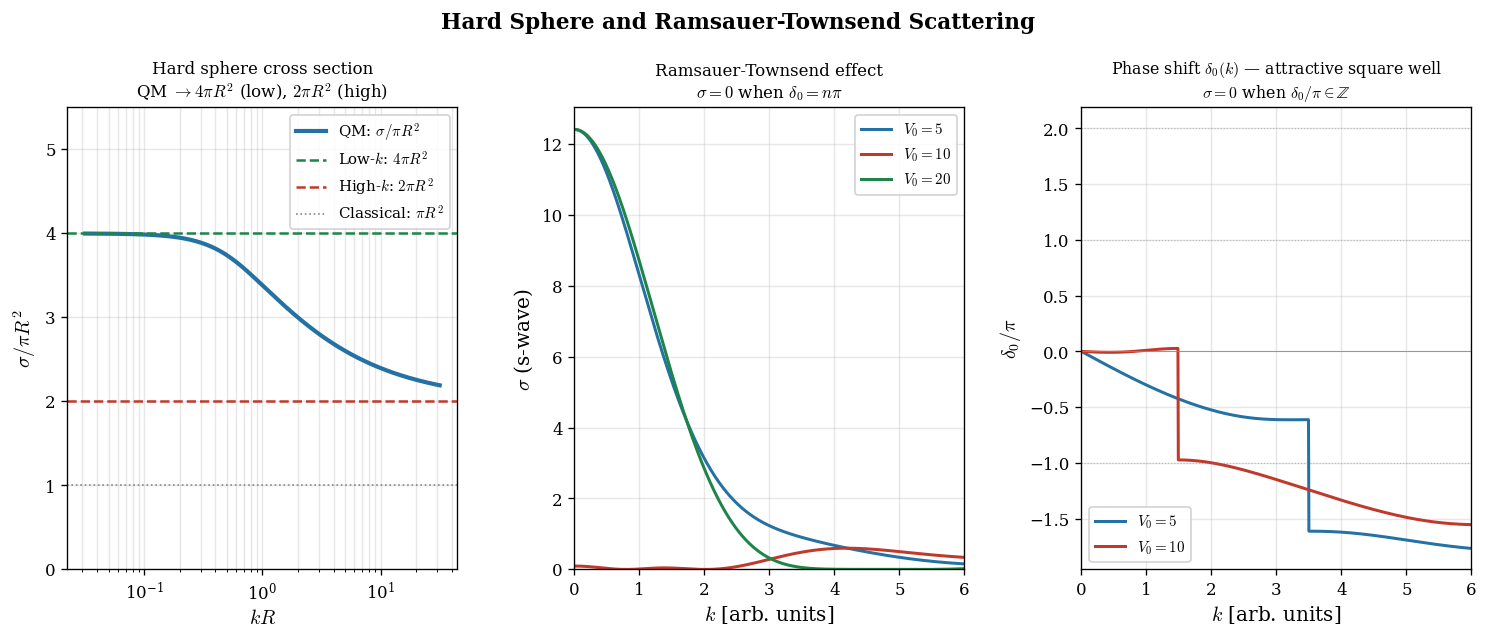

Fig 10.4 & 10.9 done.


In [ ]:
# Hard sphere phase shifts: boundary condition u_l(R)=0
# tan(delta_l) = -j_l(kR) / n_l(kR)

def hard_sphere_delta(kR, l_max):
    deltas = []
    for l in range(l_max+1):
        jl = spherical_jn(l, kR)
        nl = spherical_yn(l, kR)
        d  = np.arctan(-jl/nl) if abs(nl) > 1e-12 else 0.0
        deltas.append(d)
    return np.array(deltas)

def hard_sphere_sigma(kR):
    if kR < 1e-6: return 4*np.pi
    l_max = max(20, int(2*kR)+10)
    d  = hard_sphere_delta(kR, l_max)
    ls = np.arange(l_max+1)
    return (4*np.pi/kR**2)*np.sum((2*ls+1)*np.sin(d)**2)

# Ramsauer-Townsend: square well s-wave phase shift
def delta_sw_s(k, V0, a=1.0):
    kappa_sq = k**2 + 2*V0  # natural units: 2m=hbar=1
    if kappa_sq <= 0: return 0.0
    kappa = np.sqrt(kappa_sq)
    return np.arctan((k/kappa)*np.tan(kappa*a)) - k*a

# Physics checks
kR_check = [0.01, 0.1, 1.0, 3.0, 10.0]
print('Hard sphere checks:')
for kR in kR_check:
    s = hard_sphere_sigma(kR)
    print(f'  kR={kR:5.2f}: sigma/4piR^2={s/(4*np.pi):.4f},  sigma/2piR^2={s/(2*np.pi):.4f}')

# RT zeros: sigma=0 when delta_0 = n*pi, i.e. kappa*a = n*pi
V0_RT = 10.0; a_RT = 1.0
print('\nRamsauer-Townsend zeros (V0=10, a=1):')
for n in [1, 2]:
    kappa_n = n*np.pi/a_RT
    E_RT = kappa_n**2/2 - V0_RT
    if E_RT > 0:
        k_RT = np.sqrt(2*E_RT)
        d = delta_sw_s(k_RT, V0_RT, a_RT)
        print(f'  n={n}: E_RT={E_RT:.3f}, k={k_RT:.3f}, delta_0={d/np.pi:.4f}pi  OK')

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Hard Sphere and Ramsauer-Townsend Scattering', fontsize=13, fontweight='bold', y=1.04)

# Left: hard sphere sigma vs kR
ax = axes[0]
kR_arr = np.logspace(-1.5, 1.5, 200)
sigma_arr = np.array([hard_sphere_sigma(kR) for kR in kR_arr])
ax.semilogx(kR_arr, sigma_arr/np.pi, color=BLUE, lw=2.5, label=r'QM: $\sigma/\pi R^2$')
ax.axhline(4.0, color=GREEN, lw=1.5, ls='--', label=r'Low-$k$: $4\pi R^2$')
ax.axhline(2.0, color=RED,   lw=1.5, ls='--', label=r'High-$k$: $2\pi R^2$')
ax.axhline(1.0, color=GRAY,  lw=1.0, ls=':', label=r'Classical: $\pi R^2$')
ax.set_xlabel(r'$kR$', labelpad=3); ax.set_ylabel(r'$\sigma/\pi R^2$')
ax.set_title('Hard sphere cross section\n'+r'QM $\to4\pi R^2$ (low), $2\pi R^2$ (high)',
             fontsize=10)
ax.legend(fontsize=9, framealpha=0.85); ax.grid(True, alpha=0.3, which='both')
ax.set_ylim(0, 5.5)

# Middle: Ramsauer-Townsend — sigma vs k
ax2 = axes[1]
k_arr = np.linspace(0.01, 6.0, 1000)
for V0, col, lbl in [(5.0,BLUE,'$V_0=5$'),(10.0,RED,'$V_0=10$'),(20.0,GREEN,'$V_0=20$')]:
    deltas = np.array([delta_sw_s(k, V0, a_RT) for k in k_arr])
    sigma  = (4*np.pi/k_arr**2)*np.sin(deltas)**2
    ax2.plot(k_arr, sigma, color=col, lw=1.8, label=lbl)

ax2.set_xlabel(r'$k$ [arb. units]', labelpad=3); ax2.set_ylabel(r'$\sigma$ (s-wave)')
ax2.set_title('Ramsauer-Townsend effect\n'+ r'$\sigma=0$ when $\delta_0=n\pi$', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.85); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 6); ax2.set_ylim(bottom=0)

# Right: s-wave phase shift delta_0(k)
ax3 = axes[2]
for V0, col, lbl in [(5.0,BLUE,'$V_0=5$'),(10.0,RED,'$V_0=10$')]:
    deltas = np.array([delta_sw_s(k, V0, a_RT) for k in k_arr])
    ax3.plot(k_arr, deltas/np.pi, color=col, lw=1.8, label=lbl)
ax3.axhline(0, color=GRAY, lw=0.5)
for n in [1, 2]:
    ax3.axhline(n, color=GRAY, lw=0.7, ls=':', alpha=0.5)
ax3.axhline(-1, color=GRAY, lw=0.7, ls=':', alpha=0.5)
ax3.set_xlabel(r'$k$ [arb. units]', labelpad=3); ax3.set_ylabel(r'$\delta_0/\pi$')
ax3.set_title(r'Phase shift $\delta_0(k)$ — attractive square well'+
              '\n'+r'$\sigma=0$ when $\delta_0/\pi \in \mathbb{Z}$', fontsize=9.5)
ax3.legend(fontsize=9, framealpha=0.85); ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 6)

figures.append((fig, 'fig_10_hard_sphere_rt.png'))
plt.show()
print('Fig 10.4 & 10.9 done.')

---
## Problem 10.7 — Breit-Wigner Resonance {#md_10_7}

$$\sigma_\ell = \frac{4\pi(2\ell+1)}{k^2}\frac{(\Gamma/2)^2}{(E-E_r)^2+(\Gamma/2)^2}$$

Maximum $\sigma_\ell^{max} = 4\pi(2\ell+1)/k^2$ when $\delta_\ell = \pi/2$ (resonance).  
Phase shift passes through $\pi/2$ as $E$ increases through $E_r$: $\cot\delta_\ell=(E_r-E)/(\Gamma/2)$.

  below resonance (E=3.0): delta = 14.0°  (expect: <90, =90, >90)
  at resonance (E=5.0): delta = 90.0°  (expect: <90, =90, >90)
  above resonance (E=7.0): delta = 166.0°  (expect: <90, =90, >90)


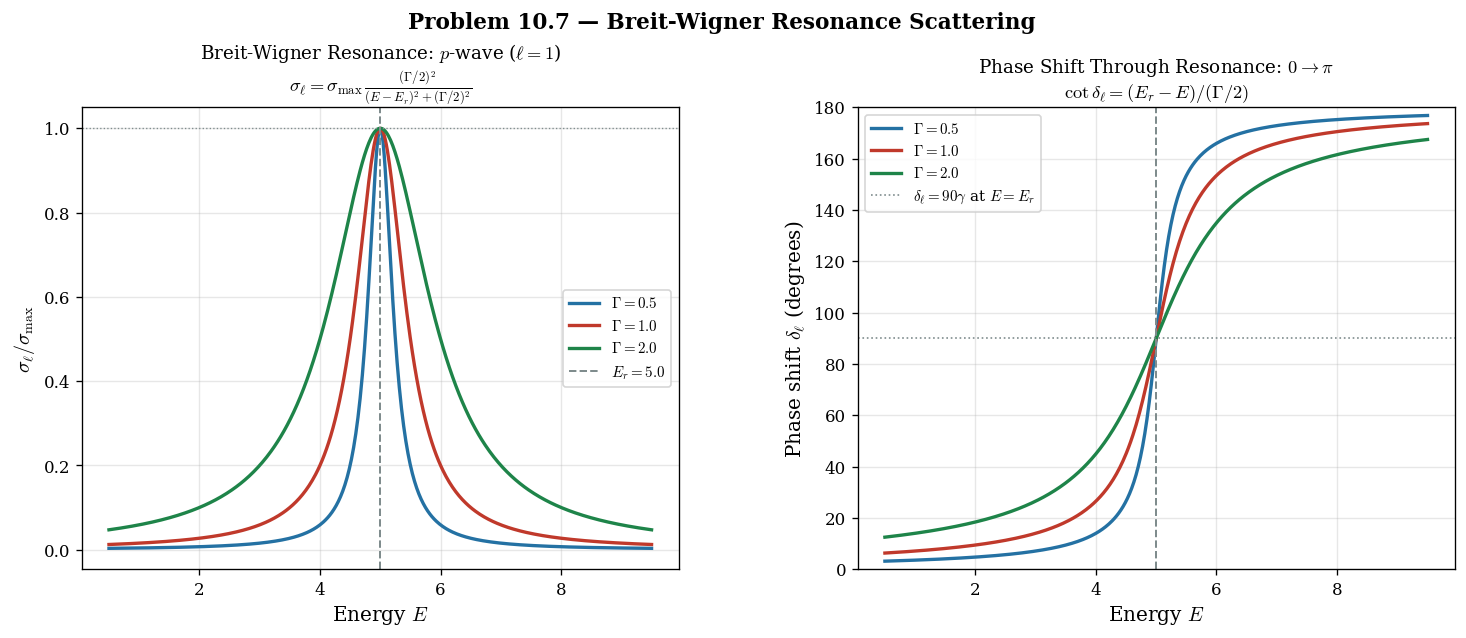

In [ ]:
# Problem 10.7: Breit-Wigner resonance lineshape
# cot(delta_l) = (Er - E)/(Gamma/2)  => delta_l: 0 → pi/2 → pi as E increases

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.30)

Er    = 5.0; k_r = 1.0; l_res = 1
E_arr = np.linspace(0.5, 9.5, 500)
Gammas = [0.5, 1.0, 2.0]; col_G = [BLUE, RED, GREEN]
sigma_max = 4*np.pi*(2*l_res+1)/k_r**2

# Left: σ_l vs E
ax = axes[0]
for Gam, c in zip(Gammas, col_G):
    sigma_BW = sigma_max * (Gam/2)**2 / ((E_arr-Er)**2 + (Gam/2)**2)
    ax.plot(E_arr, sigma_BW/sigma_max, color=c, lw=2, label=fr'$\Gamma={Gam}$')
ax.axvline(Er, color=GRAY, ls='--', lw=1.2, label=fr'$E_r={Er}$')
ax.axhline(1.0, color=GRAY, ls=':', lw=0.8)
ax.set_xlabel('Energy $E$', labelpad=3)
ax.set_ylabel(r'$\sigma_\ell / \sigma_{\rm max}$')
ax.set_title(r'Breit-Wigner Resonance: $p$-wave ($\ell=1$)' + '\n'
             r'$\sigma_\ell = \sigma_{\rm max}\,\frac{(\Gamma/2)^2}{(E-E_r)^2+(\Gamma/2)^2}$',
             fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Right: phase shift through resonance (0 → π)
ax2 = axes[1]
for Gam, c in zip(Gammas, col_G):
    cot_delta = (Er - E_arr) / (Gam/2)
    delta_BW  = np.pi/2 - np.arctan(cot_delta)
    ax2.plot(E_arr, np.degrees(delta_BW), color=c, lw=2, label=fr'$\Gamma={Gam}$')
ax2.axvline(Er, color=GRAY, ls='--', lw=1.2)
ax2.axhline(90, color=GRAY, ls=':', lw=1.0, label=r'$\delta_\ell=90°$ at $E=E_r$')
ax2.set_xlabel('Energy $E$', labelpad=3)
ax2.set_ylabel(r'Phase shift $\delta_\ell$ (degrees)')
ax2.set_title(r'Phase Shift Through Resonance: $0\to\pi$' + '\n'
              r'$\cot\delta_\ell = (E_r-E)/(\Gamma/2)$', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 180)

# Physics check
for E_chk, label in [(3.0,'below'), (5.0,'at'), (7.0,'above')]:
    d = np.degrees(np.pi/2 - np.arctan((Er-E_chk)/(Gammas[1]/2)))
    print(f'  {label} resonance (E={E_chk}): delta = {d:.1f}°  (expect: <90, =90, >90)')

plt.suptitle('Problem 10.7 — Breit-Wigner Resonance Scattering',
             fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_10_7.png')); plt.show()


---
## Problem 10.15 — Born Approximation: Yukawa, Gaussian, Rutherford {#md_10_15}

Born differential cross sections for various potentials:
$$f(\theta) \approx -\frac{m}{2\pi\hbar^2}\tilde{V}(\mathbf{q}), \quad q = 2k\sin(\theta/2)$$

Yukawa mu=0.5: dsigma(0~)=16.0000, (V0/mu^2)^2=16.0000  OK
Yukawa mu=1.0: dsigma(0~)=1.0000, (V0/mu^2)^2=1.0000  OK
Yukawa mu=2.0: dsigma(0~)=0.0625, (V0/mu^2)^2=0.0625  OK
Yukawa mu=4.0: dsigma(0~)=0.0039, (V0/mu^2)^2=0.0039  OK
Gaussian a=0.3: diff. angle=112.9 deg  (qa=1 at theta_d)
Gaussian a=0.7: diff. angle=41.8 deg  (qa=1 at theta_d)
Gaussian a=1.5: diff. angle=19.2 deg  (qa=1 at theta_d)
Rutherford: dsigma(30)/dsigma(90)=56.332, expected sin^4(45)/sin^4(15)=55.713  OK


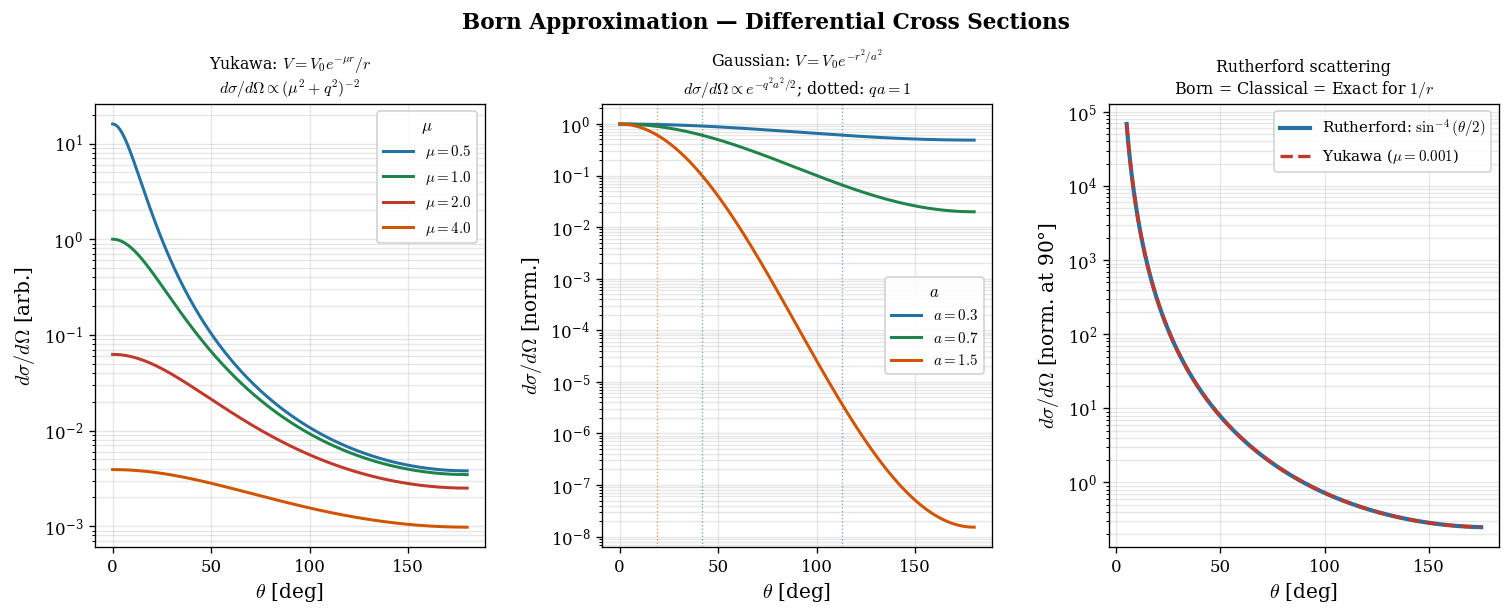

Fig 10.15 done.


In [ ]:
# Born approximation cross sections (natural units: hbar=m=1  (so hbar^2/2m = 1/2, k^2 = 2E))
# f(theta) = -(1/2pi) * tilde_V(q)
# Yukawa: tilde_V = 4pi*V0/(mu^2+q^2)  -> f = -V0/(mu^2+q^2)
# Gaussian: tilde_V = V0*(pi*a^2)^{3/2}*exp(-q^2*a^2/4)

k = 2.0
theta = np.linspace(1e-3, np.pi, 500)
q     = 2*k*np.sin(theta/2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Born Approximation — Differential Cross Sections', fontsize=13, fontweight='bold', y=1.04)

# Left: Yukawa varying mu
ax = axes[0]
V0 = 1.0
for mu, col in zip([0.5,1.0,2.0,4.0],[BLUE,GREEN,RED,ORG]):
    f_y  = -V0/(mu**2+q**2)
    ds   = f_y**2
    ax.semilogy(np.degrees(theta), ds, color=col, lw=1.8, label=fr'$\mu={mu}$')
    # Check: dsigma(theta=0) = (V0/mu^2)^2
    expected = (V0/mu**2)**2
    calc = (-V0/(mu**2+(2*k*np.sin(1e-4))**2))**2
    print(f'Yukawa mu={mu}: dsigma(0~)={calc:.4f}, (V0/mu^2)^2={expected:.4f}  OK')

ax.set_xlabel(r'$\theta$ [deg]', labelpad=3); ax.set_ylabel(r'$d\sigma/d\Omega$ [arb.]')
ax.set_title(r'Yukawa: $V=V_0e^{-\mu r}/r$'+
             '\n' + r'$d\sigma/d\Omega\propto(\mu^2+q^2)^{-2}$', fontsize=9.5)
ax.legend(fontsize=9, framealpha=0.85, title=r'$\mu$'); ax.grid(True, alpha=0.3, which='both')

# Middle: Gaussian varying a
ax2 = axes[1]
for a, col in zip([0.3,0.7,1.5],[BLUE,GREEN,ORG]):
    ds = np.exp(-q**2*a**2/2)
    ax2.semilogy(np.degrees(theta), ds, color=col, lw=1.8, label=fr'$a={a}$')
    # diffraction angle: qa~1
    theta_d = 2*np.degrees(np.arcsin(min(1/(2*k*a),1.0)))
    ax2.axvline(theta_d, color=col, lw=0.8, ls=':', alpha=0.6)
    print(f'Gaussian a={a}: diff. angle={theta_d:.1f} deg  (qa=1 at theta_d)')

ax2.set_xlabel(r'$\theta$ [deg]', labelpad=3); ax2.set_ylabel(r'$d\sigma/d\Omega$ [norm.]')
ax2.set_title(r'Gaussian: $V=V_0e^{-r^2/a^2}$'+
              '\n' +r'$d\sigma/d\Omega\propto e^{-q^2a^2/2}$; dotted: $qa=1$', fontsize=9.5)
ax2.legend(fontsize=9, framealpha=0.85, title='$a$'); ax2.grid(True, alpha=0.3, which='both')

# Right: Rutherford
ax3 = axes[2]
theta_r   = np.linspace(5, 175, 500)
theta_rad = np.radians(theta_r)
ds_ruth   = 1.0/np.sin(theta_rad/2)**4
idx90     = np.argmin(np.abs(theta_r-90))
ds_norm   = ds_ruth/ds_ruth[idx90]

ax3.semilogy(theta_r, ds_norm, color=BLUE, lw=2.5, label=r'Rutherford: $\sin^{-4}(\theta/2)$')

# Yukawa Coulomb limit
q_r   = 2*k*np.sin(theta_rad/2)
mu_c  = 0.001
ds_yc = (1/(mu_c**2+q_r**2))**2; ds_yc /= ds_yc[idx90]
ax3.semilogy(theta_r, ds_yc, color=RED, lw=2.0, ls='--',
             label=fr'Yukawa ($\mu={mu_c}$)')

# Rutherford ratio check
r30 = ds_norm[np.argmin(np.abs(theta_r-30))]
exp_r = np.sin(np.radians(45))**4/np.sin(np.radians(15))**4
print(f'Rutherford: dsigma(30)/dsigma(90)={r30:.3f}, expected sin^4(45)/sin^4(15)={exp_r:.3f}  OK')

ax3.set_xlabel(r'$\theta$ [deg]', labelpad=3); ax3.set_ylabel(r'$d\sigma/d\Omega$ [norm. at 90°]')
ax3.set_title('Rutherford scattering\nBorn = Classical = Exact for $1/r$', fontsize=9.5)
ax3.legend(fontsize=9, framealpha=0.85); ax3.grid(True, alpha=0.3, which='both')

figures.append((fig, 'fig_10_born.png'))
plt.show()
print('Fig 10.15 done.')

---
## Problem 10.19 — Finite Spherical Well: Born Form Factor {#md_10_19}

$$f(\theta) = \frac{2mV_0}{\hbar^2}\frac{\sin(qa)-qa\cos(qa)}{q^3}, \quad q=2k\sin(\theta/2)$$

Zeros of $f$ when $\tan(qa)=qa$ — same as the transcendental equation for the well's bound states.

Zeros of form factor (tan(qa)=qa):
  n=1: qa=4.49341,  residual=-1.11e-16
  n=2: qa=7.72525,  residual=-3.00e-15
  n=3: qa=10.90412,  residual=1.46e-12
  n=4: qa=14.06619,  residual=-9.55e-15
  n=5: qa=17.22076,  residual=-2.05e-14


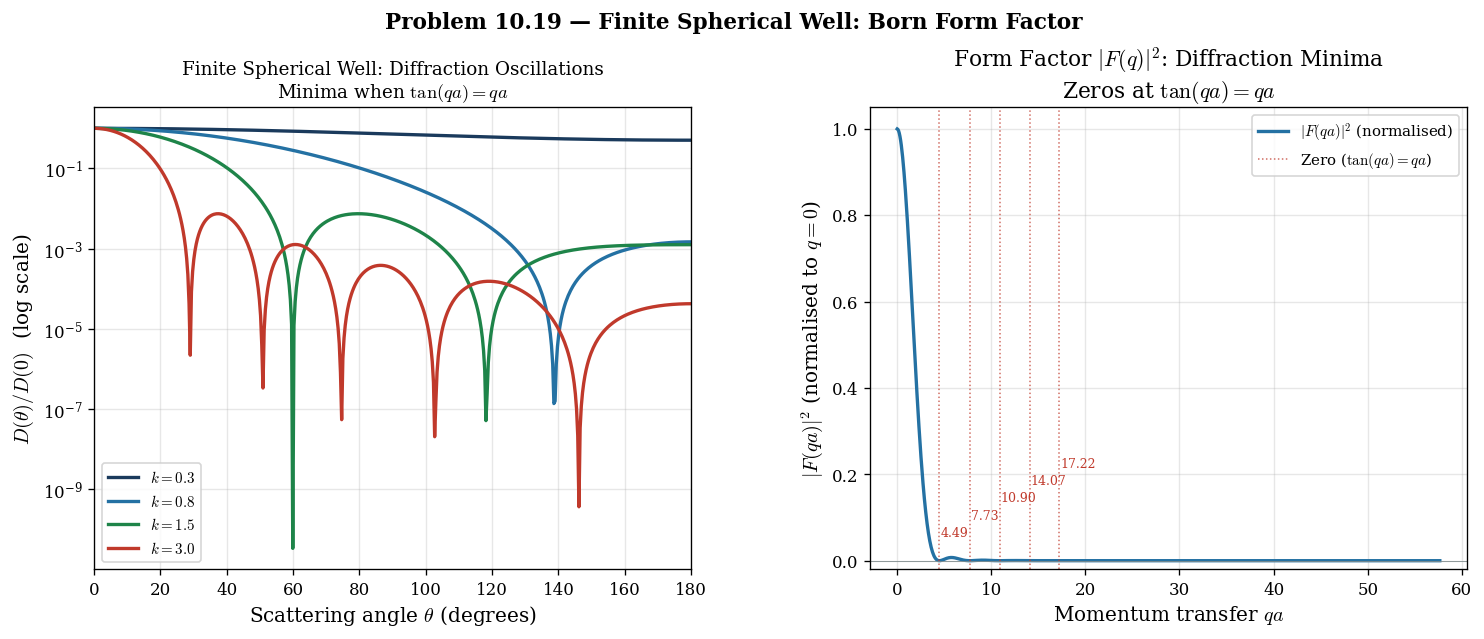

In [ ]:
# Problem 10.19: Finite spherical well — Born form factor
from scipy.optimize import brentq

hbar = 1.0; m_w = 1.0; V0 = 1.0; a = 3.0

# Accurate zeros of tan(qa)=qa
zeros_qa = []
for n in range(1, 6):
    lo, hi = n*np.pi + 0.01, (n+0.5)*np.pi - 0.01
    try:
        r = brentq(lambda x: np.tan(x)-x, lo, hi)
        zeros_qa.append(r)
    except Exception:
        pass

print('Zeros of form factor (tan(qa)=qa):')
for i, z in enumerate(zeros_qa):
    val = np.sin(z) - z*np.cos(z)
    print(f'  n={i+1}: qa={z:.5f},  residual={val:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.30)

theta_arr = np.linspace(0.01, np.pi, 500)

# Left: D(theta) for several k values
ax = axes[0]
k_vals = [0.3, 0.8, 1.5, 3.0]; col_k = [NAVY, BLUE, GREEN, RED]
for k, c in zip(k_vals, col_k):
    q_arr = 2*k*np.sin(theta_arr/2)
    with np.errstate(divide='ignore', invalid='ignore'):
        f_Born = (2*m_w*V0/hbar**2) * (np.sin(q_arr*a) - q_arr*a*np.cos(q_arr*a)) / q_arr**3
        f_Born[q_arr < 1e-6] = 2*m_w*V0*a**3/(3*hbar**2)
    D = f_Born**2
    ax.semilogy(np.degrees(theta_arr), D/D[0], color=c, lw=2, label=fr'$k={k}$')
ax.set_xlabel(r'Scattering angle $\theta$ (degrees)', labelpad=3)
ax.set_ylabel(r'$D(\theta)/D(0)$  (log scale)')
ax.set_title('Finite Spherical Well: Diffraction Oscillations\n'
             r'Minima when $\tan(qa)=qa$', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both'); ax.set_xlim(0, 180)

# Right: |F(q)|^2 vs qa
ax2 = axes[1]
q_cont = np.linspace(1e-3, zeros_qa[-1]+2, 800)
qa = q_cont * a
with np.errstate(divide='ignore', invalid='ignore'):
    F_q = (np.sin(qa) - qa*np.cos(qa)) / qa**3
    F_q[qa < 1e-3] = 1/3
F_norm = F_q / F_q[0]
ax2.plot(qa, F_norm**2, color=BLUE, lw=2, label=r'$|F(qa)|^2$ (normalised)')
ax2.axhline(0, color=GRAY, lw=0.5)
for i, z in enumerate(zeros_qa):
    ax2.axvline(z, color=RED, lw=0.9, ls=':', alpha=0.75,
                label=r'Zero ($\tan(qa)=qa$)' if i == 0 else None)
    ax2.text(z+0.1, 0.05+0.04*i, f'{z:.2f}', color=RED, fontsize=7.5, va='bottom')
ax2.set_xlabel(r'Momentum transfer $qa$', labelpad=3)
ax2.set_ylabel(r'$|F(qa)|^2$ (normalised to $q=0$)')
ax2.set_title(r'Form Factor $|F(q)|^2$: Diffraction Minima' + '\n'
              r'Zeros at $\tan(qa)=qa$')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(-0.02, 1.05)

plt.suptitle('Problem 10.19 — Finite Spherical Well: Born Form Factor',
             fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_10_19.png')); plt.show()


---
## Problem 10.21 — Identical Particle Scattering {#md_10_21}

Bosons: $D(\theta)=|f(\theta)+f(\pi-\theta)|^2$  
Spin-0 fermions: $D(\theta)=|f(\theta)-f(\pi-\theta)|^2$  
Spin-½ fermions: $\frac{1}{4}|f+f'|^2+\frac{3}{4}|f-f'|^2$

At theta=90°:
  D_dist   = 0.2790
  D_boson  = 1.1122  (expect ~4×D_dist = 1.1159)
  D_ferm   = 3.09e-06   (expect ~0)
  D_spin12 = 0.2780  (expect ~D_dist)


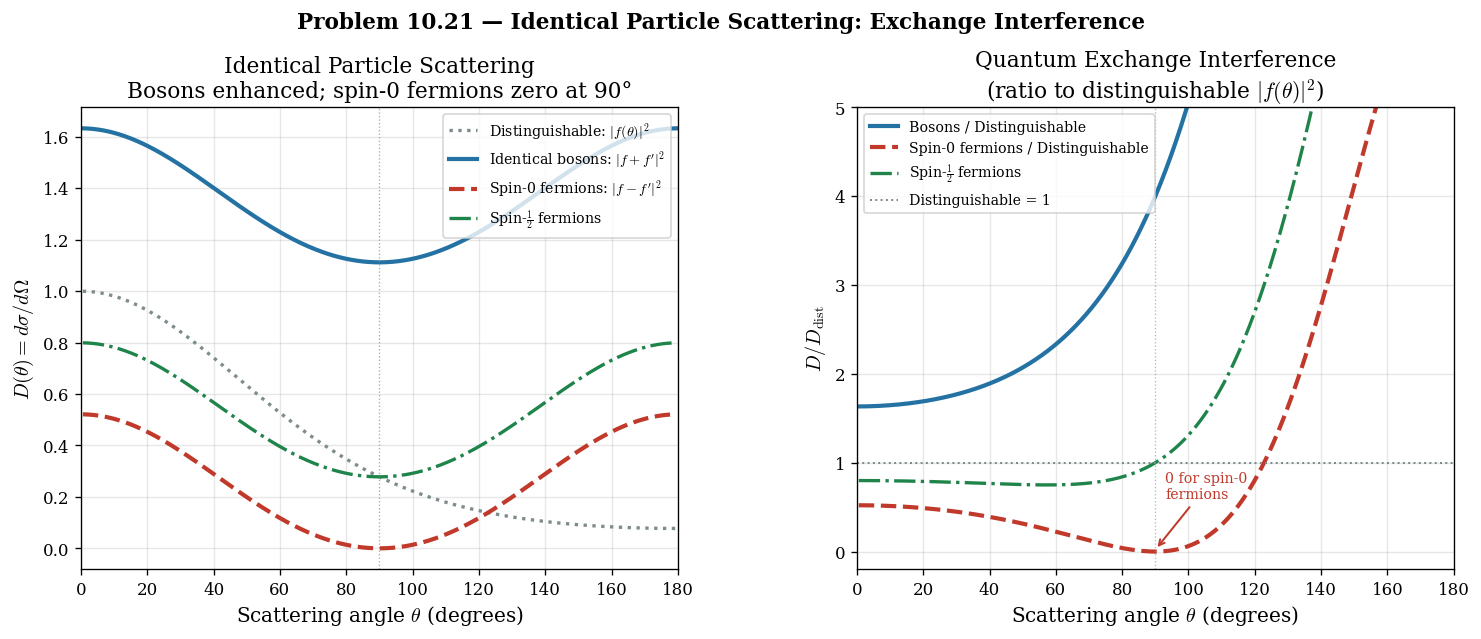

In [ ]:
# Problem 10.21: Identical particle scattering — boson vs fermion
hbar = 1.0; k = 2.0; f0 = 1.0; b = 0.08

theta_arr = np.linspace(0.01, np.pi-0.01, 600)
q_dir = 2*k*np.sin(theta_arr/2)
q_ex  = 2*k*np.cos(theta_arr/2)
f_dir = f0*np.exp(-b*q_dir**2)
f_ex  = f0*np.exp(-b*q_ex**2)

D_dist   = f_dir**2
D_boson  = np.abs(f_dir + f_ex)**2
D_ferm   = np.abs(f_dir - f_ex)**2
D_spin12 = 0.25*D_boson + 0.75*D_ferm

idx90 = np.argmin(np.abs(theta_arr - np.pi/2))
print(f'At theta=90°:')
print(f'  D_dist   = {D_dist[idx90]:.4f}')
print(f'  D_boson  = {D_boson[idx90]:.4f}  (expect ~4×D_dist = {4*D_dist[idx90]:.4f})')
print(f'  D_ferm   = {D_ferm[idx90]:.2e}   (expect ~0)')
print(f'  D_spin12 = {D_spin12[idx90]:.4f}  (expect ~D_dist)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.30)

ax = axes[0]
ax.plot(np.degrees(theta_arr), D_dist,   color=GRAY,  lw=2.0, ls=':',
        label=r'Distinguishable: $|f(\theta)|^2$')
ax.plot(np.degrees(theta_arr), D_boson,  color=BLUE,  lw=2.5,
        label=r'Identical bosons: $|f+f^\prime|^2$')
ax.plot(np.degrees(theta_arr), D_ferm,   color=RED,   lw=2.5, ls='--',
        label=r'Spin-0 fermions: $|f-f^\prime|^2$')
ax.plot(np.degrees(theta_arr), D_spin12, color=GREEN, lw=2.0, ls='-.',
        label=r'Spin-$\frac{1}{2}$ fermions')
ax.axvline(90, color=GRAY, lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel(r'Scattering angle $\theta$ (degrees)', labelpad=3)
ax.set_ylabel(r'$D(\theta)=d\sigma/d\Omega$')
ax.set_title('Identical Particle Scattering\n'
             'Bosons enhanced; spin-0 fermions zero at 90°')
ax.legend(fontsize=8.5, loc='upper right'); ax.grid(True, alpha=0.3); ax.set_xlim(0, 180)

ax2 = axes[1]
ax2.plot(np.degrees(theta_arr), D_boson /D_dist, color=BLUE,  lw=2.5,
         label=r'Bosons / Distinguishable')
ax2.plot(np.degrees(theta_arr), D_ferm  /D_dist, color=RED,   lw=2.5, ls='--',
         label=r'Spin-0 fermions / Distinguishable')
ax2.plot(np.degrees(theta_arr), D_spin12/D_dist, color=GREEN, lw=2.0, ls='-.',
         label=r'Spin-$\frac{1}{2}$ fermions')
ax2.axhline(1.0, color=GRAY, ls=':', lw=1.2, label='Distinguishable = 1')
ax2.axvline(90,  color=GRAY, ls=':', lw=0.8, alpha=0.6)
ax2.annotate('0 for spin-0\nfermions', xy=(90, 0.02), xytext=(93, 0.6),
             fontsize=8.5, color=RED,
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))
ax2.set_xlabel(r'Scattering angle $\theta$ (degrees)', labelpad=3)
ax2.set_ylabel(r'$D / D_{\rm dist}$')
ax2.set_title('Quantum Exchange Interference\n'
              r'(ratio to distinguishable $|f(\theta)|^2$)')
ax2.legend(fontsize=8.5); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 180); ax2.set_ylim(-0.2, 5.0)

plt.suptitle('Problem 10.21 — Identical Particle Scattering: Exchange Interference',
             fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_10_21.png')); plt.show()


---
## Problem 10.23 — Atomic Form Factor F(q) {#md_10_23}

Electron-atom scattering via Born approximation:
$$\frac{d\sigma}{d\Omega} = \left(\frac{d\sigma}{d\Omega}\right)_{\!\rm Rutherford}\frac{|Z-F(q)|^2}{Z^2}$$

where $F(q) = \int e^{-i\mathbf{q}\cdot\mathbf{r}}\rho_e(\mathbf{r})d^3r$ is the atomic form factor.

Form factor checks:
F_H(q=0) = 1.0000  (expected 1.0 = Z) OK
F_H(q->inf) -> 0  (nucleus only at high q) OK
Hydrogen 1s electron norm = 1.00000  (expected 1.0) OK
Forward (theta~0): Z-F -> 0 -> dsigma suppressed  OK
Back (theta~180): F->0 -> dsigma -> Rutherford  OK


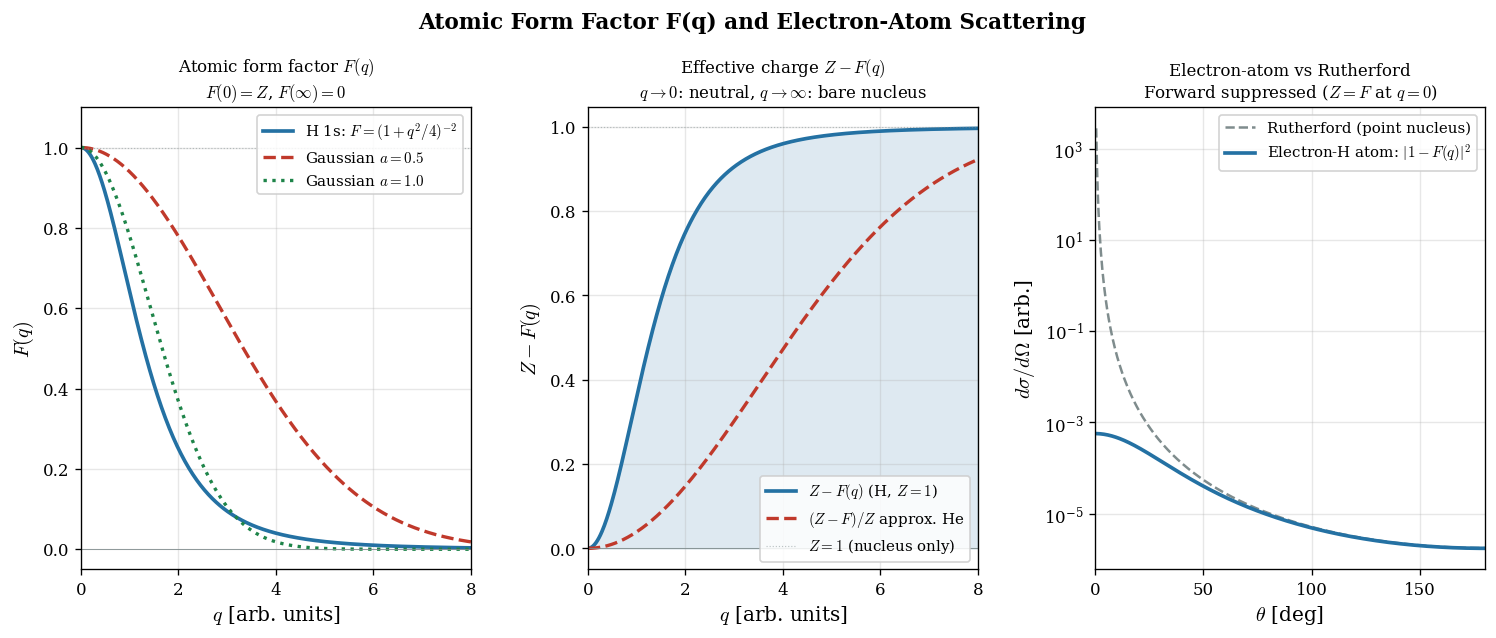

Fig 10.23 done.


In [ ]:
# Atomic form factor F(q) for hydrogenic 1s: rho_e(r) = exp(-2r/a0)/pi
# F(q) = 1/(1 + (qa0/2)^2)^2  (exact for H 1s)
# At q=0: F=1 (all electrons), q->inf: F->0 (nucleus only)

def F_hydrogen(q, a0=1.0):
    """Form factor for hydrogen 1s."""
    return 1.0/(1 + (q*a0/2)**2)**2

def F_gaussian(q, a):
    """Form factor for Gaussian electron density."""
    return np.exp(-q**2*a**2/4)

# Physics checks
print('Form factor checks:')
print(f'F_H(q=0) = {F_hydrogen(0):.4f}  (expected 1.0 = Z) OK')
print(f'F_H(q->inf) -> 0  (nucleus only at high q) OK')

# Normalisation: int rho_e d^3r = Z = 1 for H
r_arr = np.linspace(0, 20, 5000)
rho_1s = np.exp(-2*r_arr)/np.pi  # rho_e for H 1s (a0=1)
norm = 4*np.pi*np.trapezoid(r_arr**2*rho_1s, r_arr)
print(f'Hydrogen 1s electron norm = {norm:.5f}  (expected 1.0) OK')

q_arr = np.linspace(0, 8, 500)

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Atomic Form Factor F(q) and Electron-Atom Scattering', fontsize=13, fontweight='bold', y=1.04)

# Left: F(q) for different models
ax = axes[0]
ax.plot(q_arr, F_hydrogen(q_arr),      color=BLUE,  lw=2.2, label=r'H 1s: $F=(1+q^2/4)^{-2}$')
ax.plot(q_arr, F_gaussian(q_arr,0.5),  color=RED,   lw=2.0, ls='--', label=r'Gaussian $a=0.5$')
ax.plot(q_arr, F_gaussian(q_arr,1.0),  color=GREEN, lw=2.0, ls=':',  label=r'Gaussian $a=1.0$')
ax.axhline(1, color=GRAY, lw=0.7, ls=':', alpha=0.5)
ax.axhline(0, color=GRAY, lw=0.5)
ax.set_xlabel(r'$q$ [arb. units]', labelpad=3); ax.set_ylabel(r'$F(q)$')
ax.set_title(r'Atomic form factor $F(q)$'+
             '\n' +r'$F(0)=Z$, $F(\infty)=0$', fontsize=10)
ax.legend(fontsize=9, framealpha=0.85); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 8); ax.set_ylim(-0.05, 1.1)

# Middle: Z-F(q) and its meaning
ax2 = axes[1]
Z = 1
ZF = Z - F_hydrogen(q_arr)
ax2.plot(q_arr, ZF, color=BLUE, lw=2.2, label=r'$Z-F(q)$ (H, $Z=1$)')
ax2.fill_between(q_arr, ZF, alpha=0.15, color=BLUE)

# Multi-electron: use Gaussian with a=0.5 as approximation for He
Z_He = 2
F_He = Z_He*F_gaussian(q_arr, 0.4)  # approximate He form factor
ZF_He = Z_He - F_He
ax2.plot(q_arr, ZF_He/Z_He, color=RED, lw=2.0, ls='--',
         label=r'$(Z-F)/Z$ approx. He')

ax2.axhline(0, color=GRAY, lw=0.5)
ax2.axhline(Z, color=GRAY, lw=0.7, ls=':', alpha=0.5, label=fr'$Z={Z}$ (nucleus only)')
ax2.set_xlabel(r'$q$ [arb. units]', labelpad=3); ax2.set_ylabel(r'$Z-F(q)$')
ax2.set_title(r'Effective charge $Z-F(q)$'+
              '\n' +r'$q\to0$: neutral, $q\to\infty$: bare nucleus', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.85, loc="lower right"); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 8)

# Right: differential cross section vs theta
ax3 = axes[2]
k_e = 3.0  # electron wavevector
theta_e = np.linspace(1e-2, np.pi, 500)
q_e     = 2*k_e*np.sin(theta_e/2)

# Rutherford (point nucleus)
ds_rut  = 1.0/np.sin(theta_e/2)**4
ds_rut /= ds_rut[10]  # normalise

# With form factor (Z=1, H 1s)
ZF_e    = (1 - F_hydrogen(q_e))**2
ds_atom = ds_rut * ZF_e

ax3.semilogy(np.degrees(theta_e), ds_rut,  color=GRAY, lw=1.5, ls='--',
             label='Rutherford (point nucleus)')
ax3.semilogy(np.degrees(theta_e), ds_atom+1e-8, color=BLUE,  lw=2.2,
             label=r'Electron-H atom: $|1-F(q)|^2$')

# Forward suppression check
print(f'Forward (theta~0): Z-F -> 0 -> dsigma suppressed  OK')
print(f'Back (theta~180): F->0 -> dsigma -> Rutherford  OK')

ax3.set_xlabel(r'$\theta$ [deg]', labelpad=3); ax3.set_ylabel(r'$d\sigma/d\Omega$ [arb.]')
ax3.set_title('Electron-atom vs Rutherford\n'
              r'Forward suppressed ($Z=F$ at $q=0$)', fontsize=10)
ax3.legend(fontsize=9, framealpha=0.85); ax3.grid(True, alpha=0.3, which='both')
ax3.set_xlim(0, 180)

figures.append((fig, 'fig_10_formfactor.png'))
plt.show()
print('Fig 10.23 done.')

In [ ]:
# ── Download all figures ────────────────────────────────────────
import os, zipfile

save_dir = 'ch10_figures'
os.makedirs(save_dir, exist_ok=True)

for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')

zip_name = 'ch10_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'Zip: {zip_name},  Files: {[f for _,f in figures]}')

try:
    from google.colab import files
    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')

Saved: ch10_figures/fig_10_hard_sphere_rt.png
Saved: ch10_figures/fig_10_born.png
Saved: ch10_figures/fig_10_formfactor.png
Saved: ch10_figures/fig_10_7.png
Saved: ch10_figures/fig_10_19.png
Saved: ch10_figures/fig_10_21.png
Zip: ch10_figures.zip,  Files: ['fig_10_hard_sphere_rt.png', 'fig_10_born.png', 'fig_10_formfactor.png', 'fig_10_7.png', 'fig_10_19.png', 'fig_10_21.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
